In [1]:
from utils.dependencies import *;

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
synthdata = pickle.load(open("./massive_data/2026-05-19-reference.pkl", "rb"))["data"]
synth_bins = synthdata[synthdata["is_binary"] == True]
periods = np.array([np.log10(s["period"]) for s in synth_bins]) 
in_period_mask = (periods >= 1.75) & (periods <= 3.5)
synth_bins = synth_bins[in_period_mask]
synth_nss = synthdata[synthdata["solution_type"] == 12]

In [3]:
orbit_solutions = Table.read("./data/2026_05_19_orbit_solutions.fits", format="fits")

In [4]:
hist_setups = {
    "lw": 5,
    "baseline": None
}
parent_setup = {
    "lw": 5,
    "baseline": None,
    "color": "firebrick", 
    "zorder": 0, 
    "alpha": 0.4
}

### Eccentricities

In [ ]:
eccentricity_bins = np.linspace(0,1,15)

vals, bins = np.histogram(orbit_solutions["eccentricity"], bins=eccentricity_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_nss], bins=eccentricity_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_bins], bins=eccentricity_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

plt.xlabel("Eccentricity");
plt.ylabel("Percentage");
plt.legend();

In [ ]:
eccentricity_bins = np.linspace(0,1,1000)

vals, bins = np.histogram(orbit_solutions["eccentricity"], bins=eccentricity_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_nss], bins=eccentricity_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_bins], bins=eccentricity_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

plt.xlabel("Eccentricity");
plt.ylabel("Cumulative Percentage");
plt.legend();

### Period

In [ ]:
period_bins = np.linspace(1.8,3.5,15)

vals, bins = np.histogram(np.log10(orbit_solutions["period"]), bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_nss], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_bins], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

plt.xlabel(r"Log$_{10}T$");
plt.ylabel("Percentage");
plt.legend();

In [ ]:
period_bins = np.linspace(1.8,3.5,1000)

vals, bins = np.histogram(np.log10(orbit_solutions["period"]), bins=period_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_nss], bins=period_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_bins], bins=period_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

plt.xlabel(r"Log$_{10}T$");
plt.ylabel("Cumulative Percentage");
plt.legend();

### Mass Ratio

In [ ]:
q_bins = np.linspace(0.05,0.35,15)

vals, bins = np.histogram(orbit_solutions["m2"]/orbit_solutions["mass_single"], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_nss], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_bins], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

plt.xlabel(r"Mass Ratio");
plt.ylabel("Percentage");
plt.legend();

In [ ]:
q_bins = np.linspace(0.05,0.4,1000)

vals, bins = np.histogram(orbit_solutions["m2"]/orbit_solutions["mass_single"], bins=q_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_nss], bins=q_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_bins], bins=q_bins)
cdf_vals = np.cumsum(vals/np.sum(vals)*100)
plt.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

plt.xlabel(r"Mass Ratio");
plt.ylabel("Cumulative Percentage");
plt.legend();

### Final Plot

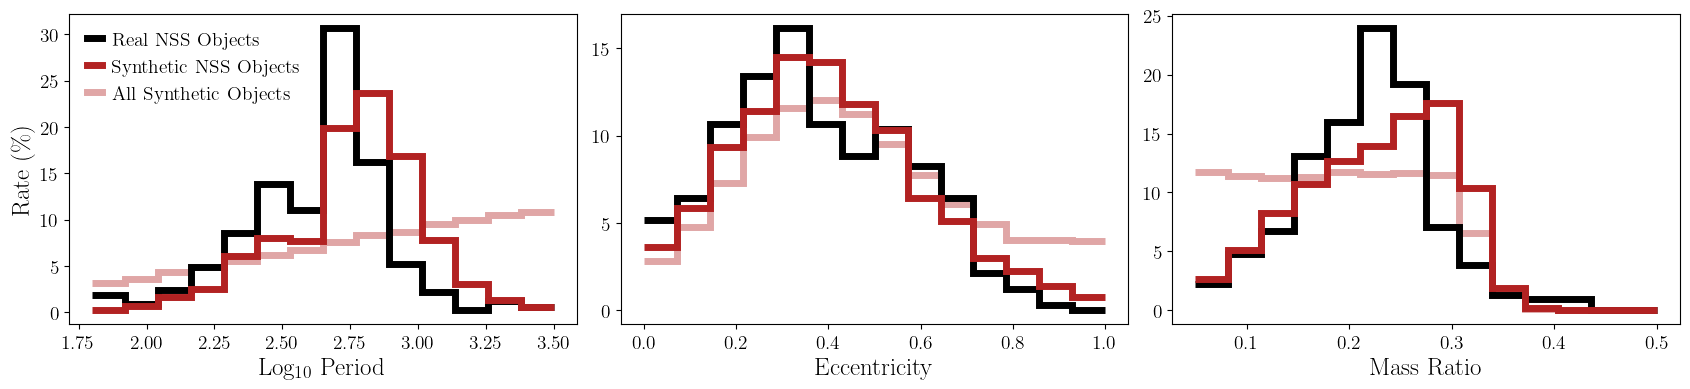

In [5]:
fig, axs = plt.subplots(1,3, figsize=(17,4))

### PERIOD ###
ax = axs[0]
period_bins = np.linspace(1.8,3.5,15)

vals, bins = np.histogram(np.log10(orbit_solutions["period"]), bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_nss], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([np.log10(s["period"]) for s in synth_bins], bins=period_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel(r"Log$_{10}$ Period");
ax.set_ylabel("Rate (\%)");
ax.legend(handletextpad=0.5);

### ECCENTRICITY ###
ax = axs[1]
eccentricity_bins = np.linspace(0,1,15)

vals, bins = np.histogram(orbit_solutions["eccentricity"], bins=eccentricity_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_nss], bins=eccentricity_bins)
ecc_nss_vals = vals/np.sum(vals)*100
ax.stairs(ecc_nss_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["ecc"] for s in synth_bins], bins=eccentricity_bins)
ecc_all_vals = vals/np.sum(vals)*100
ax.stairs(ecc_all_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel("Eccentricity");

### MASS RATIO ###
ax = axs[2]
q_bins = np.linspace(0.05,0.5,15)

#vals, bins = np.histogram(orbit_solutions["m2_binary"]/orbit_solutions["m1_binary"], bins=q_bins)
vals, bins = np.histogram(orbit_solutions["m2"]/orbit_solutions["mass_single"], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_nss], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_bins], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
ax.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

ax.set_xlabel(r"Mass Ratio");

plt.tight_layout()
plt.savefig("./plots/selection_function_correction.pdf", transparent=True, dpi=800)

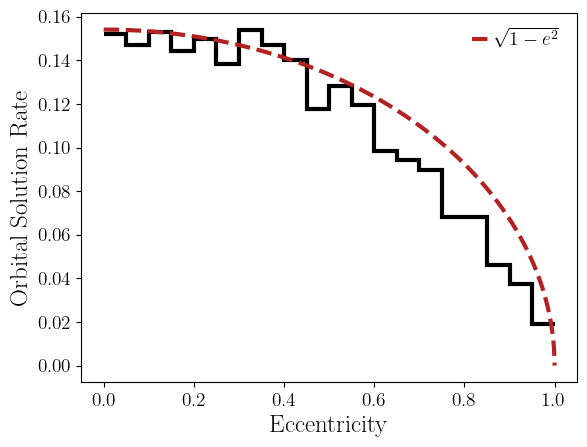

In [59]:
finer_bins = np.linspace(0,1,21)
nss_vals, bins = np.histogram([s["ecc"] for s in synth_nss], bins=finer_bins)
all_vals, bins = np.histogram([s["ecc"] for s in synth_bins], bins=finer_bins)
rates = nss_vals/all_vals
plt.stairs(rates, bins, baseline=None, lw=3);
es = np.linspace(0,1,1000)
plt.plot(es, np.sqrt(1-es**2)*np.max(rates), color="firebrick", lw=3, ls="--", label=r"$\sqrt{1-e^2}$");
plt.legend();
plt.xlabel("Eccentricity");
plt.ylabel("Orbital Solution Rate");

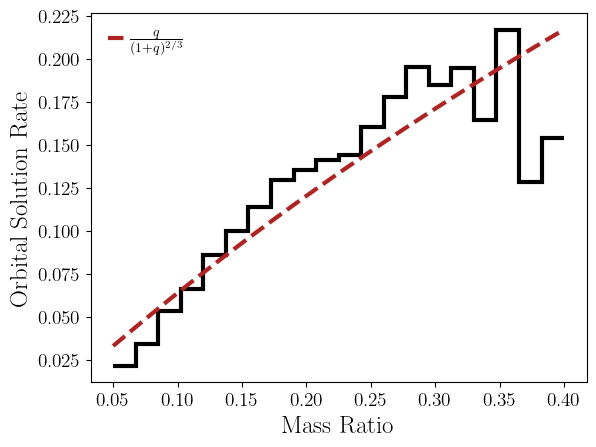

In [56]:
finer_bins = np.linspace(0.05,0.4,21)
nss_vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_nss], bins=finer_bins)
all_vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_bins], bins=finer_bins)
rates = nss_vals/all_vals
plt.stairs(rates, bins, baseline=None, lw=3);
qs = np.linspace(0.05,0.4,1000)
tst = qs/(1+qs)**(2/3)
tst = tst / np.max(tst)
plt.plot(qs, tst*np.nanmax(rates), color="firebrick", lw=3, ls="--", label=r"$\frac{q}{(1+q)^{2/3}}$");
plt.legend();
plt.xlabel("Mass Ratio");
plt.ylabel("Orbital Solution Rate");

In [15]:
mdwarfs = Table.read('./massive_data/06_05_26_final_table.fits', format='fits')
len(mdwarfs[mdwarfs["solution_type"] == 12])

487

In [14]:
len(orbit_solutions)

487

## mass-averaged volume correction

the goal here is to make a function $v(M_1)$ to correct for the $17.65$ g-cutoff for the XP spectra.

we can't do this object-wise because this doesn't consider that orbit solutions might be `limited' but this is captured by gaiamock

we will do this by taking a rolling average

In [3]:
main_table = Table.read('./data/0306_final_catalogue.fits', format='fits')
effective_volumes = np.array([relative_volume(main_table[i]["phot_g_mean_mag"], main_table[i]["parallax"]) for i in range(len(main_table))])

In [ ]:
bp_rp = main_table["bp_rp"]
parallax = main_table["parallax"]
gmag = main_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

plt.scatter(absolute_magnitudes, effective_volumes, s=10, color="k", alpha=0.1);

In [6]:
main_table["mass"] = main_table["mass_single"]

In [7]:
rolling_volumes = generate_rolling_average(main_table)

In [8]:
masses = main_table["mass"]

In [8]:
i=0

In [ ]:
i+=1

f"{i}: {masses[i]:.2f}, {rolling_volumes[i]:.2f}"

In [ ]:
plt.scatter(main_table["mass"], 1/rolling_volumes)

In [6]:
masses = main_table["mass_single"]

# sort volumes according to increasing mass
sorted_indices = np.argsort(masses)
sorted_masses = masses[sorted_indices]
sorted_volumes = effective_volumes[sorted_indices]

In [26]:
rolling_average = np.convolve(sorted_volumes, np.ones(10000)/10000, mode='same')

In [27]:
new_rolling_average = np.zeros(len(rolling_average))

for i in range(len(rolling_average)):
    keep = True
    if i > 0:
        keep = new_rolling_average[i-1] < rolling_average[i]
        
    if keep:
        new_rolling_average[i] = rolling_average[i]
    else:
        new_rolling_average[i] = new_rolling_average[i-1]

In [33]:
resorted_averages = np.zeros(len(new_rolling_average))
for i in range(len(new_rolling_average)):
    resorted_averages[sorted_indices[i]] = new_rolling_average[i]

In [ ]:
plt.scatter(masses, resorted_averages);

In [ ]:
plt.scatter(main_table["mass_single"], effective_volumes, s=10, color="k", alpha=0.1);
plt.plot(sorted_masses, rolling_average, color="C1", linewidth=2);
plt.plot(sorted_masses, new_rolling_average, color="C2", linewidth=2);

## Setup

In [58]:
synthdata0204 = pickle.load(open("./massive_data/2026-03-29-final_0204.pkl", "rb"))["data"]
synth_bins = synthdata0204[[s["is_binary"] == True for s in synthdata0204]]
periods = np.array([np.log10(s["period"]) for s in synth_bins])
in_period_mask = (periods >= 1.75) & (periods <= 3.5)
synth_bins = synth_bins[in_period_mask]
synth_nss = synthdata0204[[s["solution_type"] == 12 for s in synthdata0204]]

In [26]:
main_table_02 = Table.read('./data/0204_final_catalogue.fits', format='fits')
orbit_solutions_02 = main_table_02[main_table_02["solution_type"] == 12]

In [ ]:
q_bins = np.linspace(0.05,0.5,15)

vals, bins = np.histogram(orbit_solutions["m2_binary"]/orbit_solutions["m1_binary"], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Real NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_nss], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **hist_setups, label="Synthetic NSS Objects")

vals, bins = np.histogram([s["m2"]/s["mass"] for s in synth_bins], bins=q_bins)
cdf_vals = vals/np.sum(vals)*100
plt.stairs(cdf_vals, bins, **parent_setup, label="All Synthetic Objects")

plt.xlabel(r"Mass Ratio");
plt.ylabel("Percentage");
plt.legend();

In [ ]:
job = Gaia.launch_job_async(f"""
                            SELECT *
                            FROM gaiadr3.nss_two_body_orbit
                            WHERE source_id = 5484601704313935488
                            """, verbose=False)
results_single = job.get_results()
results_single.remove_column("corr_vec")

In [5]:
import os
os.environ["XDG_CACHE_HOME"] = os.path.expanduser("~/.astroquery_tmp")

In [6]:
import time

In [ ]:
def chunk_list(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 25  # Gaia can usually handle 50-100 IDs per query

all_results = []

for batch in tqdm(list(chunk_list(orbit_solutions["source_id"], batch_size))):
    success = False
    while not success:
        try:
            ids_str = ",".join(str(sid) for sid in batch)
            query = f"""
                SELECT *
                FROM gaiadr3.nss_two_body_orbit
                WHERE source_id IN ({ids_str})
                AND parallax > 5
                """
            job = Gaia.launch_job_async(query, verbose=False)
            results = job.get_results()
            all_results.append(results.to_pandas())
            success = True
        except Exception as e:
            print(f"Error querying batch: {e}. Retrying...")
            time.sleep(2)

df = pd.concat(all_results, ignore_index=True)
results = Table.from_pandas(df)
results.remove_column("corr_vec")

In [71]:
results.remove_column("corr_vec")

In [ ]:
ids = orbit_solutions["source_id"]
ids_str = ",".join(str(sid) for sid in ids)
query = f"""
SELECT *
FROM gaiadr3.nss_two_body_orbit
WHERE source_id IN ({ids_str})
"""
job = Gaia.launch_job_async(query, verbose=False)
results = job.get_results()
results.remove_column("corr_vec")

In [ ]:
results

In [ ]:
es = np.linspace(np.min(results["eccentricity"]), np.max(results["eccentricity"]), 1000)
pes = Sampler.gaussian(es, 0.38, 0.2)
pes = pes / np.trapz(pes, es)

In [ ]:
pts = Sampler.pexp(es, 1)   
pts = pts / np.trapz(pts, es)

In [ ]:
plt.hist(results["eccentricity"], bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k");
plt.plot(es, np.cumsum(pes) * (es[1] - es[0]), color="C1", linewidth=2, label="Gaussian");
plt.plot(es, np.cumsum(pts) * (es[1] - es[0]), color="C0", linewidth=2, label="Thermal");
plt.title("Eccentricity");
plt.legend();

In [ ]:
periods = np.log10(results["period"])
ps = np.linspace(1.8,3,1000)
pps = Sampler.gaussian(ps, 4, 1.3)
pps = pps / np.trapz(pps, ps)

In [ ]:
plt.hist(periods[(periods > 2) & (periods < 3)], bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k");
plt.plot(ps, np.cumsum(pps) * (ps[1] - ps[0]), color="C2", linewidth=2);
plt.title("Period");

In [8]:
labels = ["period", "eccentricity", "m2", "t_periastron", "fm", "m2_flux"]
for label in labels:
    try:
        orbit_solutions.add_column(np.zeros(len(orbit_solutions)), name=label)
    except:
        pass

In [ ]:
for row in orbit_solutions:
    result_row = results[results["source_id"] == row["source_id"]]
    row["fm"] = mass_function(result_row[0])
    row["m2"] = companion_mass(row["mass_single"], row["fm"])
    row["m2_flux"] = companion_mass_phot(row["mass_single"], row["fm"], row["flux_ratio_mean"])
    row["period"] = result_row["period"][0]
    row["eccentricity"] = result_row["eccentricity"][0]
    row["t_periastron"] = result_row["t_periastron"][0] / result_row["period"][0]

In [ ]:
plt.scatter(orbit_solutions_02["m2"], orbit_solutions_02["m2_flux"]);
plt.axline((0,0), slope=1, **dline);

In [ ]:
tests = []
for row in orbit_solutions_02:
    tests.append(companion_mass_phot(row["mass_single"], row["fm"], row["flux_ratio_mean"]))
tests = np.array(tests)

In [10]:
orbit_solutions.write('./data/0306_orbit_solutions.fits', format='fits', overwrite=True)

In [ ]:
reasonable_mask = (orbit_solutions["m2"]/orbit_solutions["mass_single"]) < 1.0
mass_ratios = (orbit_solutions["m2"]/orbit_solutions["mass_single"])[reasonable_mask]

#mass_ratios = orbit_solutions["q_binary"]
qs = np.linspace(0.05, 0.3, 1000) #np.max(mass_ratios), 1000)
qps = Sampler.pexp(qs, 0.5)
qps = qps / np.trapz(qps, qs)

qps1 = Sampler.pexp(qs, 1)
qps1 = qps1 / np.trapz(qps1, qs)

qps0 = Sampler.pexp(qs, 0)
qps0 = qps0 / np.trapz(qps0, qs)
plt.hist(mass_ratios, bins=100, histtype="step", range=(0,0.3), cumulative=True, density=True, linewidth=2, color="k");
plt.plot(qs, np.cumsum(qps0) * (qs[1] - qs[0]), color="C7", linewidth=2, label="0");
plt.plot(qs, np.cumsum(qps) * (qs[1] - qs[0]), color="C1", linewidth=2, label="0.5");
plt.plot(qs, np.cumsum(qps1) * (qs[1] - qs[0]), color="C6", linewidth=2, label="1");
plt.legend();
plt.title("Mass Ratio");

In [48]:
import style

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Eccentricity
axes[0].hist(results["eccentricity"], bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k")
axes[0].plot(es, np.cumsum(pes) * (es[1] - es[0]), color="C1", linewidth=2, label="Gaussian");
axes[0].plot(es, np.cumsum(pts) * (es[1] - es[0]), color="C0", linewidth=2, label="Thermal");
axes[0].set_title("Eccentricity");
axes[0].legend();

# Period
axes[1].hist(np.log10(results["period"]), bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k", range=(np.min(periods),3))
axes[1].plot(ps, np.cumsum(pps) * (ps[1] - ps[0]), color="C2", linewidth=2);
axes[1].set_title("Period")

# Mass Ratio
axes[2].hist(mass_ratios, bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k")
axes[2].plot(qs, np.cumsum(qps) * (qs[1] - qs[0]), color="C4", linewidth=2, label=r"$\gamma=0.5$")
axes[2].plot(qs, np.cumsum(qps1) * (qs[1] - qs[0]), color="C3", linewidth=2, label=r"$\gamma=1$");
axes[2].legend();
axes[2].set_title("Mass Ratio")

plt.tight_layout()

## etc

In [22]:
import sys
import os
folder_a_path = os.path.abspath(os.path.join(os.getcwd(), '../BHPopulation'))
if folder_a_path not in sys.path:
    sys.path.append(folder_a_path)
    
import GaiamockWrapper as gw

In [24]:
def generate_parallax(resolution=1000):
    # sample a distance from a distribution that goes as d^2 between 100 and 200
    # from inverse cdf sampling
    dist_range = (50, 200)
    dists = np.linspace(*dist_range, resolution)
    d_pdf = np.zeros_like(dists)
    d_pdf[1:] = Sampler.pexp(dists[1:], 2)
    d_cdf = np.cumsum(d_pdf / np.sum(d_pdf))
    d = np.interp(np.random.rand(), d_cdf, dists)
    parallax = 1000 / d 
    return parallax

In [4]:
areas = np.array([relative_volume(main_table[i]["phot_g_mean_mag"], main_table[i]["parallax"]) for i in range(len(main_table))])

In [ ]:
plt.scatter(main_table["mass_single"], areas, c="k", s=1, alpha=0.5);

In [ ]:
1000/125

In [102]:
using_table = main_table[main_table["parallax"]>8]

In [ ]:
tbinsh = plt.hist(1000/using_table[using_table["mass_single"]>0.38]["parallax"], bins=50, histtype="step", cumulative=False, density=False, linewidth=2, color="k");
tbinsm = plt.hist(1000/using_table[(using_table["mass_single"]>0.3) & (using_table["mass_single"]<0.32)]["parallax"], bins=50, histtype="step", cumulative=False, density=False, linewidth=2, color="brown");
tbinsl = plt.hist(1000/using_table[using_table["mass_single"]<0.25]["parallax"], bins=50, histtype="step", cumulative=False, linewidth=2, density=False, color="grey");
plt.yscale('log');

In [ ]:
plt.stairs(np.cumsum(tbinsh[0])/np.max(np.cumsum(tbinsh[0])), tbinsh[1], color="slateblue", label=r"$0.38<M$");
plt.stairs(np.cumsum(tbinsm[0])/np.max(np.cumsum(tbinsm[0])), tbinsm[1], color="forestgreen", label=r"$0.3<M<0.31$");
plt.stairs(np.cumsum(tbinsl[0])/np.max(np.cumsum(tbinsl[0])), tbinsl[1], color="firebrick", label=r"$M<0.25$");
plxs = np.linspace(100,1000/8,1000)
plt.plot(plxs, np.cumsum(Sampler.pexp(plxs, 2))/np.max(np.cumsum(Sampler.pexp(plxs, 2))), color="C1", linewidth=2);
plt.legend();

In [ ]:
plt.scatter(orbit_solutions["eccentricity"], orbit_solutions["mass_single"], s=10, color="k", alpha=0.5);

In [ ]:
plt.hist([1000/generate_parallax() for _ in range(10000)], bins=25, histtype="step", cumulative=False, density=True, linewidth=2, color="k");
plt.hist(1000/main_table["parallax"], bins=25, histtype="step", cumulative=False, linewidth=2, density=True, color="grey");
plt.yscale('log');
ax = plt.twinx()
plxs = np.linspace(100,200,1000)
ax.plot(plxs, Sampler.pexp(plxs, 2), color="C1", linewidth=2);
#ax.set_ylim(bottom=0);
ax.set_yscale("log");

In [37]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

In [ ]:
def compute_rate(i, sample_count=50, extra_count=250):
    m1 = orbit_solutions["mass_single"][i]

    solrate = gw.marginalize_solution_type(
        sample_count=sample_count,
        only_full=True,
        diagnose=False,
        m1=m1,
        q=orbit_solutions["m2"][i] / m1,
        f=1e-10,
        parallax=orbit_solutions["parallax"][i],
        phot_g_mean_mag=orbit_solutions["phot_g_mean_mag"][i],
        period=orbit_solutions["period"][i],
        ecc=orbit_solutions["eccentricity"][i],
        catalogue=main_table,
        marginalize_angles=True,
        marginalize_position=True,
        marginalize_pm=True,
        verbose=False)
    
    count = np.sum(solrate == 12)
    rate = count / sample_count

    # for rare objects, do many more iterations
    if count == 0:
        solrate = gw.marginalize_solution_type(
            sample_count=extra_count,
            only_full=True,
            diagnose=False,
            m1=m1,
            q=orbit_solutions["m2"][i] / m1,
            f=1e-10,
            parallax=orbit_solutions["parallax"][i],
            phot_g_mean_mag=orbit_solutions["phot_g_mean_mag"][i],
            period=orbit_solutions["period"][i],
            ecc=orbit_solutions["eccentricity"][i],
            catalogue=main_table,
            marginalize_angles=True,
            marginalize_position=True,
            marginalize_pm=True,
            verbose=False)
        
        count += np.sum(solrate == 12)
        rate = count / (sample_count + extra_count)
        
    return rate

rates = Parallel(n_jobs=-1,          # use all cores
                backend="loky",     # default, process-based
)(
    delayed(compute_rate)(i)
    for i in tqdm(range(len(orbit_solutions))))

rates = np.array(rates)

In [75]:
outdata = dict()
outdata["rates"] = rates 
outfile = open("./plot_data/rates_0306.pkl", "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [12]:
rates = np.array(pickle.load(open("./plot_data/rates.pkl", "rb"))["rates"])

In [ ]:
adj_rates = rates.astype(float)
adj_rates[adj_rates == 0] = np.min(adj_rates[adj_rates > 0])

In [ ]:
reasonable_mask = (orbit_solutions["m2"]/orbit_solutions["mass_single"]) < 0.4
masked_sols = orbit_solutions[reasonable_mask]
masked_rates = rates[reasonable_mask]
mass_ratios = (masked_sols["m2"]/masked_sols["mass_single"])

#mass_ratios = orbit_solutions["q_binary"]

new_mass_ratios = []
for i in range(len(mass_ratios)):
    for _ in range(int(np.max(masked_rates)/np.maximum(masked_rates[i], np.min(masked_rates[masked_rates > 0])))):
        new_mass_ratios.append(mass_ratios[i])
    #tbins[0][np.minimum(inds[i]-1, 24)] += 100 - rates[i]

plt.hist(mass_ratios, bins=100, histtype="step", range=(0,0.4), cumulative=True, density=True, linewidth=2, color="k");
plt.hist(new_mass_ratios, bins=100, histtype="step", range=(0,0.4), cumulative=True, density=True, linewidth=2, color="red");

In [ ]:
new_eccs = []
for i in range(len(masked_sols)):
    for _ in range(int(np.max(masked_rates)/np.maximum(masked_rates[i], np.min(masked_rates[masked_rates > 0])))):
        new_eccs.append(masked_sols[i]["eccentricity"])
    #tbins[0][np.minimum(inds[i]-1, 24)] += 100 - rates[i]

plt.hist(masked_sols["eccentricity"], bins=1000, histtype="step", cumulative=True, density=True, linewidth=2, color="k");
plt.hist(new_eccs, bins=1000, histtype="step", cumulative=True, density=True, linewidth=2, color="red");

In [ ]:
#period_mask = np.log10(orbit_solutions["period"]) < 3
#periods = np.log10(orbit_solutions["period"])[period_mask]
#tbins = np.histogram(periods, bins=25)
#inds = np.searchsorted(tbins[1], periods, side="right")
new_periods = []
for i in range(len(masked_sols)):
    for _ in range(int(np.max(masked_rates)/np.maximum(masked_rates[i], np.min(masked_rates[masked_rates > 0])))):
        new_periods.append(np.log10(masked_sols[i]["period"]))
    #tbins[0][np.minimum(inds[i]-1, 24)] += 100 - rates[i]

plt.hist(np.log10(masked_sols["period"]), bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k", range=(np.min(periods),3));
plt.hist(new_periods, bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="red", range=(np.min(periods),3));
#cumulative_bins = np.cumsum(tbins[0])
#plt.plot(tbins[1][:-1]+(tbins[1][1:]-tbins[1][:-1])/2, cumulative_bins/np.max(cumulative_bins))

In [89]:
qg = Sampler.gaussian(qs, 0.24, 0.07)
qg = qg / np.trapezoid(qg, qs)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Eccentricity
axes[0].hist(results["eccentricity"], bins=100, histtype="step", cumulative=True, density=True, linewidth=1, color="k", linestyle=":")
axes[0].hist(new_eccs, bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k")
axes[0].plot(es, np.cumsum(pes) * (es[1] - es[0]), color="C1", linewidth=2, label="Gaussian");
axes[0].plot(es, np.cumsum(pts) * (es[1] - es[0]), color="C0", linewidth=2, label="Thermal");
axes[0].set_title("Eccentricity");
axes[0].legend();

# Period
axes[1].hist(np.log10(results["period"]), bins=100, histtype="step", cumulative=True, density=True, linewidth=1, color="k", range=(np.min(periods),3), linestyle=":")
axes[1].hist(new_periods, bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k", range=(np.min(periods),3))
axes[1].plot(ps, np.cumsum(pps) * (ps[1] - ps[0]), color="C2", linewidth=2)
axes[1].set_title("Period")

# Mass Ratio
axes[2].hist(mass_ratios, bins=100, histtype="step", range=(0,0.3), cumulative=True, density=True, linewidth=1, color="k", linestyle=":")
axes[2].hist(new_mass_ratios, bins=100, histtype="step", range=(0,0.3), cumulative=True, density=True, linewidth=2, color="k")
axes[2].plot(qs, np.cumsum(qps0) * (qs[1] - qs[0]), color="C6", linewidth=2, label=r"$\gamma=0$")
axes[2].plot(qs, np.cumsum(qps) * (qs[1] - qs[0]), color="C3", linewidth=2, label=r"$\gamma=0.5$")
axes[2].plot(qs, np.cumsum(qps1) * (qs[1] - qs[0]), color="C4", linewidth=2, label=r"$\gamma=1$");
#axes[2].plot(qs, np.cumsum(qg) * (qs[1] - qs[0]), color="C5", linewidth=2, label=r"Gaussian");
axes[2].legend();
axes[2].set_title("Mass Ratio")

plt.tight_layout()

In [83]:
import style

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6, 12))

# Eccentricity
axes[0].hist(results["eccentricity"], bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k", linestyle=":")
axes[0].hist(new_eccs, bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k")
axes[0].plot(es, np.cumsum(pes) * (es[1] - es[0]), color="Green", linewidth=2, label="Gaussian");
axes[0].plot(es, np.cumsum(pts) * (es[1] - es[0]), color="Red", linewidth=2, label="Thermal");
axes[0].set_xlabel("Eccentricity");
axes[0].set_ylabel("Cumulative Fraction");
#axes[0].legend();

# Period
axes[1].hist(np.log10(results["period"]), bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k", range=(1.8,3), linestyle=":")
axes[1].hist(new_periods, bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k", range=(1.8,3))
axes[1].plot(ps, np.cumsum(pps) * (ps[1] - ps[0]), color="Green", linewidth=2)
axes[1].set_xlabel(r"$\text{Log}T$");
axes[1].set_ylabel("Cumulative Fraction");

# Mass Ratio
axes[2].hist(mass_ratios, bins=100, range=(0.05,0.3), histtype="step", cumulative=True, density=True, linewidth=1, color="k", linestyle=":")
axes[2].hist(new_mass_ratios, bins=100, range=(0.05,0.3), histtype="step", cumulative=True, density=True, linewidth=2, color="k")
#axes[2].plot(qs, np.cumsum(qps) * (qs[1] - qs[0]), color="Green", linewidth=2, label=r"$\gamma=0.5$")
axes[2].plot(qs, np.cumsum(qps0) * (qs[1] - qs[0]), color="Green", linewidth=2, label=r"$\gamma=0$");
#axes[2].plot(qs, np.cumsum(qg) * (qs[1] - qs[0]), color="k", linestyle="--", linewidth=2, label=r"Gaussian");
#axes[2].legend();
axes[2].set_xlabel("Mass Ratio");
axes[2].set_ylabel("Cumulative Fraction");

plt.tight_layout()
plt.savefig("./plots/SelectionInversion.pdf", dpi=800)

In [ ]:
def step_cdf(ax, data, bins=100, range=None, **kwargs):
    hist, edges = np.histogram(
        data, bins=bins, range=range, density=True
    )
    cdf = np.cumsum(hist) * np.diff(edges)
    ax.plot(edges[:-1], cdf, drawstyle="steps-pre", **kwargs)

fig, axes = plt.subplots(3, 1, figsize=(6, 12), sharey=True)

# Eccentricity
step_cdf(
    axes[0], results["eccentricity"],
    bins=100, color="k", linestyle=":", linewidth=2
)
step_cdf(
    axes[0], new_eccs,
    bins=100, color="k", linewidth=2
)
axes[0].plot(es, np.cumsum(pes) * (es[1] - es[0]),
             color="Green", linewidth=2, label="Gaussian")
axes[0].plot(es, np.cumsum(pts) * (es[1] - es[0]),
             color="Red", linewidth=2, label="Thermal")
axes[0].set_xlabel("Eccentricity")
axes[0].set_ylabel("Cumulative Fraction")

# Period
step_cdf(
    axes[1], np.log10(results["period"]),
    bins=100, range=(np.min(periods), 3),
    color="k", linestyle=":", linewidth=2
)
step_cdf(
    axes[1], new_periods,
    bins=100, range=(np.min(periods), 3),
    color="k", linewidth=2
)
axes[1].plot(ps, np.cumsum(pps) * (ps[1] - ps[0]),
             color="Green", linewidth=2)
axes[1].set_xlabel(r"$\text{Log}_{10}T$")
axes[1].set_ylabel("Cumulative Fraction")

# Mass Ratio
step_cdf(
    axes[2], mass_ratios,
    bins=100, color="k", linestyle=":", linewidth=1
)
step_cdf(
    axes[2], new_mass_ratios,
    bins=100, color="k", linewidth=2
)
axes[2].plot(qs, np.cumsum(qps) * (qs[1] - qs[0]),
             color="Green", linewidth=2, label=r"$\gamma=0.5$")
axes[2].plot(qs, np.cumsum(qps0) * (qs[1] - qs[0]),
             color="Red", linewidth=2, label=r"$\gamma=0$")
axes[2].plot(qs, np.cumsum(qg) * (qs[1] - qs[0]),
             color="k", linestyle="--", linewidth=2, label="Gaussian")
axes[2].set_xlabel("Mass Ratio")
axes[2].set_ylabel("Cumulative Fraction")

axes[0].set_ylim(bottom=0)
plt.tight_layout()
#plt.savefig("./plots/SelectionInversion.pdf", dpi=800)

## Completeness

In [ ]:
indices = [0,5,7,9,12]
all_mdwarfs = []
relevant_list = ["parallax", "mass", "solution_type", "phot_g_mean_mag"]

mdwarfs = Table.read('./data/200pc_mdwarfs_reduced.fits', format='fits')
masses = np.array([row["mass_single"] for row in mdwarfs])
percs = np.percentile(masses, np.arange(0, 110, 10))
for row in tqdm(mdwarfs):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs) - 1, 9)
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_mdwarfs.append(df)
all_mdwarfs = np.array(all_mdwarfs)

In [ ]:
tbins = plt.hist(1000/mdwarfs["parallax"], histtype="step", color="k");
plt.hist(1000/mdwarfs[mdwarfs["mass_single"]<0.25]["parallax"], histtype="step", bins=tbins[1], label="<0.25");
plt.hist(1000/mdwarfs[mdwarfs["mass_single"]>0.38]["parallax"], histtype="step", bins=tbins[1], label=">0.38");
plt.legend();

In [ ]:
tbins = plt.hist(mdwarfs["phot_g_mean_mag"], histtype="step", color="k");
plt.hist(mdwarfs[mdwarfs["mass_single"]<0.25]["phot_g_mean_mag"], histtype="step", bins=tbins[1]);
plt.hist(mdwarfs[mdwarfs["mass_single"]>0.38]["phot_g_mean_mag"], histtype="step", bins=tbins[1]);

In [ ]:
tbins = plt.hist2d(1000/mdwarfs["parallax"], mdwarfs["phot_g_mean_mag"], bins=100);

In [ ]:
plt.hist2d(1000/mdwarfs[mdwarfs["mass_single"]<0.25]["parallax"], mdwarfs[mdwarfs["mass_single"]<0.25]["phot_g_mean_mag"], bins=len(tbins[1]));

In [ ]:
plt.hist2d(1000/mdwarfs[mdwarfs["mass_single"]>0.38]["parallax"], mdwarfs[mdwarfs["mass_single"]>0.38]["phot_g_mean_mag"], bins=len(tbins[1]));

# Selection Function Inversion

How this clueless PhD student inverted the selection function in three easy steps! (doctors of philosophy HATE him)

1. For each orbit solution in your sample, take its fit period, eccentricity, primary and secondary masses (alongside on-sky positions and proper motions)
2. Simulate the astrometry many many times with random orbital angles and distance (adjusting the magnitude in turn, ensuring the magnitude remains within your desirable range)
    - The rate $\frac{1}{N_i}$ means the object corresponds to $N_i$ objects in total
3. Create new histograms by adjusting the counts so each object now has its representative count $N_i$

These histograms correspond to the parent sample :)

In [8]:
import numpy as np
from scipy.stats import truncnorm
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import utils.GaiamockWrapperLite as gw

In [9]:
nss_catalogue = results
input_table = orbit_solutions

In [10]:
def sample_normal(row, label, count=1):
    mean = row[label]
    scale = row[label + "_error"]
    
    scale = np.maximum(scale, 1e-5)

    # -1, +1 indicate truncating to 1 sigma
    samples = truncnorm.rvs(-0.5, 0.5, loc=mean, scale=scale, size=count)

    return samples[0] if count == 1 else samples

def adjust_magnitude(mag, plx, new_plx):
    """Adjust the magnitude of a star to reflect a change in parallax."""
    # Calculate the absolute magnitude
    abs_mag = mag - 5 * np.log10(1000/plx) + 5
    
    # Calculate the new apparent magnitude
    new_mag = abs_mag + 5 * np.log10(1000/new_plx) - 5
    return new_mag

def generate_parallaxes(dist_range=(50,200), count=1, resolution=1000):
    # sample a distance from a distribution that goes as d^2 between 100 and 200
    # from inverse cdf sampling
    dists = np.linspace(*dist_range, resolution)
    d_pdf = np.zeros_like(dists)
    d_pdf[1:] = pexp(dists[1:], 2) # d^2
    d_cdf = np.cumsum(d_pdf / np.sum(d_pdf))
    d = np.interp(np.random.rand(count), d_cdf, dists)
    parallax = 1000 / d 
    if count == 1:
        return parallax[0]
    return parallax

def select_parallaxes(ref_plx, ref_mag, count=1, dist_range=(50,200), resolution=1000):
    '''
        Select parallaxes for a star, ensuring that the resulting magnitudes are below the XP limit of 17.65.
    '''
    parallaxes = generate_parallaxes(dist_range=dist_range, count=count, resolution=resolution)
    magnitudes = adjust_magnitude(ref_mag, ref_plx, parallaxes)
    # reselect parallaxes until all magnitudes are below the limit
    bad = magnitudes > 17.65
    while np.any(bad):
        parallaxes[bad] = generate_parallaxes(dist_range=dist_range, count=np.sum(bad), resolution=resolution)
        magnitudes[bad] = adjust_magnitude(ref_mag, ref_plx, parallaxes[bad])
        bad = magnitudes > 17.65
    return parallaxes, magnitudes

def simulate_many_realisations(input_row, nss_row, sample_count, q, m1, f, ra, dec, pmra, pmdec, t, t_mod, c_funcs):
    # choose period, eccentricity from uncertainty of the solution within 1sigma
    # clipping just in case (but it should never actually come up)
    periods = np.clip(sample_normal(nss_row, "period", sample_count), 100, 10000)
    eccentricities = np.clip(sample_normal(nss_row, "eccentricity", sample_count), 0, 0.98)
    
    # choose parallax isotropically over the volume of space, limiting to G=17.65 
    ref_plx = input_row["parallax"]
    ref_mag = input_row["phot_g_mean_mag"]
    parallaxes, magnitudes = select_parallaxes(ref_plx, ref_mag, count=sample_count)

    Tps = np.random.uniform(-0.5, 0.5, sample_count)
    ws = np.random.uniform(0, 2*np.pi, sample_count)
    omegas = np.random.uniform(0, 2*np.pi, sample_count)
    incs = np.arccos(np.random.uniform(-1, 1, sample_count))

    counts = 0

    for j in range(sample_count):
        soltype = gw.rapid_solution_type(
            periods[j], q, parallaxes[j], m1, magnitudes[j], f,
            eccentricities[j], incs[j], ws[j], omegas[j], Tps[j],
            ra, dec, pmra, pmdec, t, t_mod, c_funcs,
            skip_full=False, return_ruwe=False, return_fits=False
        )

        if soltype == 12:
            counts += 1
    
    return counts
            
def compute_rate(i, sample_count=50, extra_count=250, f=1e-10):
    try:
        # Initialize per-process (safe for multiprocessing)
        c_funcs = gw.generate_cfuncs()

        input_row = input_table[i]
        nss_row_filtered = nss_catalogue[nss_catalogue["source_id"] == int(input_row["source_id"])]

        if len(nss_row_filtered) == 0:
            raise ValueError(f"No matching NSS entry for source_id {input_row['source_id']}")
        
        # Extract the first row to get Row object instead of Table
        nss_row = nss_row_filtered[0]

        # Extract values
        ra = nss_row["ra"]
        dec = nss_row["dec"]
        pmra = nss_row["pmra"]
        pmdec = nss_row["pmdec"]

        m1 = input_row["mass_single"]
        q = input_row["m2"] / m1

        # Generate scanning law
        t, t_mod = gw.generate_scanning_times(ra, dec)

        # simulate a bunch of binaries! For the binaries that often get orbit solutions, we only need a few samples
        counts = simulate_many_realisations(input_row, nss_row, sample_count, q, m1, f, ra, dec, pmra, pmdec, t, t_mod, c_funcs)
        rate = counts / sample_count

        # if none get an orbit solution, sample even more to get a better resolution for just the rare ones
        if counts == 0 and extra_count > 0:
            counts = simulate_many_realisations(input_row, nss_row, extra_count, q, m1, f, ra, dec, pmra, pmdec, t, t_mod, c_funcs)

            rate = counts / (sample_count + extra_count)

        return rate

    except Exception as e:
        print(f"[ERROR] index {i}: {e}")
        return np.nan

# Parallel execution
def compute_all_rates(**kwargs):
    rates = np.empty(len(orbit_solutions))

    with ProcessPoolExecutor() as executor:
        futures = {
            executor.submit(compute_rate, i, **kwargs): i
            for i in range(len(orbit_solutions))
        }

        for future in tqdm(as_completed(futures), total=len(futures)):
            idx = futures[future]
            try:
                rates[idx] = future.result()
            except Exception as e:
                print(f"[FUTURE ERROR] index {idx}: {e}")
                rates[idx] = np.nan

    return rates

In [ ]:
rates = compute_all_rates(sample_count=100, extra_count=250)

In [24]:
outdata = dict()
outdata["rates"] = rates 
outfile = open("./plot_data/rates.pkl", "wb")
pickle.dump(outdata, outfile)
outfile.close()

In [ ]:
rates = np.array(pickle.load(open("./plot_data/rates.pkl", "rb"))["rates"])

In [ ]:
plt.hist(rates)

In [ ]:
plt.scatter(np.log10(masked_sols["period"]), 1/masked_rates);

In [ ]:
plt.scatter(masked_sols["eccentricity"], 1/masked_rates);

In [ ]:
valid_mask = (~np.isnan(rates))
reasonable_mask = (orbit_solutions["m2"]/orbit_solutions["mass_single"]) < 0.4
masked_sols = orbit_solutions[reasonable_mask & valid_mask]
masked_rates = rates[reasonable_mask & valid_mask]
mass_ratios = (masked_sols["m2"]/masked_sols["mass_single"])

#mass_ratios = orbit_solutions["q_binary"]

new_mass_ratios = []
for i in range(len(mass_ratios)):
    for _ in range(int(np.max(masked_rates)/np.maximum(masked_rates[i], np.min(masked_rates[masked_rates > 0])))):
        new_mass_ratios.append(mass_ratios[i])
    #tbins[0][np.minimum(inds[i]-1, 24)] += 100 - rates[i]

plt.hist(mass_ratios, bins=100, histtype="step", range=(0,0.4), cumulative=True, density=True, linewidth=2, color="k");
plt.hist(new_mass_ratios, bins=100, histtype="step", range=(0,0.4), cumulative=True, density=True, linewidth=2, color="red");

In [ ]:
new_eccs = []
for i in range(len(masked_sols)):
    for _ in range(int(np.max(masked_rates)/np.maximum(masked_rates[i], np.min(masked_rates[masked_rates > 0])))):
        new_eccs.append(masked_sols[i]["eccentricity"])
    #tbins[0][np.minimum(inds[i]-1, 24)] += 100 - rates[i]

plt.hist(masked_sols["eccentricity"], bins=1000, histtype="step", cumulative=True, density=True, linewidth=2, color="k");
plt.hist(new_eccs, bins=1000, histtype="step", cumulative=True, density=True, linewidth=2, color="red");
plt.plot(es, np.cumsum(pes) * (es[1] - es[0]), linewidth=2, label="Gaussian", ls="--");
plt.plot(es, np.cumsum(pts) * (es[1] - es[0]), linewidth=2, label="Thermal", ls="--");

In [ ]:
#period_mask = np.log10(orbit_solutions["period"]) < 3
#periods = np.log10(orbit_solutions["period"])[period_mask]
#tbins = np.histogram(periods, bins=25)
#inds = np.searchsorted(tbins[1], periods, side="right")
new_periods = []
for i in range(len(masked_sols)):
    for _ in range(int(np.max(masked_rates)/np.maximum(masked_rates[i], np.min(masked_rates[masked_rates > 0])))):
        new_periods.append(np.log10(masked_sols[i]["period"]))
    #tbins[0][np.minimum(inds[i]-1, 24)] += 100 - rates[i]

plt.hist(np.log10(masked_sols["period"]), bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="k", range=(1.8,3));
plt.hist(new_periods, bins=100, histtype="step", cumulative=True, density=True, linewidth=2, color="red", range=(1.8,3));
#cumulative_bins = np.cumsum(tbins[0])True
#plt.plot(tbins[1][:-1]+(tbins[1][1:]-tbins[1][:-1])/2, cumulative_bins/np.max(cumulative_bins))

In [ ]:
#period_mask = np.log10(orbit_solutions["period"]) < 3
#periods = np.log10(orbit_solutions["period"])[period_mask]
#tbins = np.histogram(periods, bins=25)
#inds = np.searchsorted(tbins[1], periods, side="right")
new_periods = []
for i in range(len(masked_sols)):
    for _ in range(int(np.max(masked_rates)/np.maximum(masked_rates[i], np.min(masked_rates[masked_rates > 0])))):
        new_periods.append(np.log10(masked_sols[i]["period"]))
    #tbins[0][np.minimum(inds[i]-1, 24)] += 100 - rates[i]

plt.hist(np.log10(masked_sols["period"]), bins=25, histtype="step", cumulative=False, density=True, linewidth=2, color="k", range=(1.8,3));
plt.hist(new_periods, bins=25, histtype="step", cumulative=False, density=True, linewidth=2, color="red", range=(1.8,3));
#cumulative_bins = np.cumsum(tbins[0])True
#plt.plot(tbins[1][:-1]+(tbins[1][1:]-tbins[1][:-1])/2, cumulative_bins/np.max(cumulative_bins))